# Experiment 5

---


## Reinforcement Learning Using Python

---
<br>


**Name:** Sakshi Bhatt<br>
**SAP ID:** 500121811 <br>
**Roll No:** R2142230740<br>
**Batch:** B8<br>
**Course:** Algorithms for Intelligent Systems and Robotics Lab


## 1. Aim
To implement Reinforcement Learning using Q-Learning in Python and train an agent to find the optimal path in a simple environment.


## 2. Objectives
- Understand the basic concept of Reinforcement Learning.
- Understand Agent, Environment, State, Action and Reward.
- Implement the Q-Learning algorithm using Python.
- Observe how an agent learns through trial and error.


## 3. Theory
Reinforcement Learning (RL) is a type of machine learning in which an agent learns by interacting with an environment. The agent is not given any correct answer, it takes an action, sees the reward, and slowly understands which actions are useful.

The agent:
- observes the current state
- performs an action
- receives a reward or a penalty
- learns which actions produce better rewards

Q-Learning stores the expected reward of taking an action in a particular state using a Q-table. The Q value is updated using:

$$Q(s,a)=Q(s,a)+\alpha[r+\gamma\max_{a'}Q(s',a')-Q(s,a)]$$

where $\alpha$ = learning rate, $\gamma$ = discount factor, $r$ = reward, $s$ = current state, $a$ = action, and $s'$ = next state.


## 4. Requirements
**Software:** Python 3.x, NumPy, Jupyter Notebook / Google Colab


## 5. Algorithm
1. Initialize the Q-table with zeros.
2. Select the current state.
3. Choose an action using an exploration strategy.
4. Perform the action and observe the reward.
5. Update the Q-value.
6. Move to the next state.
7. Repeat until the goal is reached.
8. Train the agent for multiple episodes.
9. Display the learned optimal path.


## 6. Python Program
A 4x4 grid world is used. The cells are numbered 0 to 15, the agent starts at 0 and the goal is 15.

```text
 0  1  2  3
 4  5  6  7
 8  9 10 11
12 13 14 15
```


In [1]:
import numpy as np
import random

random.seed(3)  # so that the result stays same on every run

# 4x4 Grid World
# Start = 0, Goal = 15
states = 16
actions = 4  # 0=Up, 1=Down, 2=Left, 3=Right
Q = np.zeros((states, actions))

alpha = 0.8    # Learning rate
gamma = 0.95   # Discount factor
epsilon = 0.2  # Exploration rate
episodes = 1000

print("Q-table before training :")
print(Q[:4], "...")


Q-table before training :
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] ...


The `next_state` function converts the state number into a row and a column using `divmod`, applies the action, and converts it back into a state number. If the move goes outside the grid the agent stays in the same cell.


In [2]:
def next_state(state, action):
    row, col = divmod(state, 4)
    if action == 0 and row > 0:      # Up
        row -= 1
    elif action == 1 and row < 3:    # Down
        row += 1
    elif action == 2 and col > 0:    # Left
        col -= 1
    elif action == 3 and col < 3:    # Right
        col += 1
    return row * 4 + col

for a in range(4):
    print("from state 6, action", a, "goes to state", next_state(6, a))


from state 6, action 0 goes to state 2
from state 6, action 1 goes to state 10
from state 6, action 2 goes to state 5
from state 6, action 3 goes to state 7


Training. One episode is one complete attempt, from state 0 till state 15. The visits of every state are also counted, it is used later for a heatmap.


In [3]:
steps_per_episode = []
visits = np.zeros(16)  # extra, counting how many times each state is visited

# Training
for episode in range(episodes):
    state = 0
    steps = 0
    while state != 15:
        visits[state] += 1

        # Exploration or exploitation
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            action = np.argmax(Q[state])

        new_state = next_state(state, action)

        # Reward
        reward = 10 if new_state == 15 else -1

        # Q-learning update
        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state, action]
        )

        state = new_state
        steps += 1

    steps_per_episode.append(steps)

print("training over,", episodes, "episodes")
print("total moves made by the agent while training :", int(visits.sum()))


training over, 1000 episodes
total moves made by the agent while training : 7547


In [4]:
# Display learned path
state = 0
path = [state]
while state != 15:
    action = np.argmax(Q[state])
    state = next_state(state, action)
    path.append(state)

print("Learned Optimal Path:")
print(path)


Learned Optimal Path:
[0, 4, 8, 12, 13, 14, 15]


## 7. Output
The learned path has 6 moves which is the smallest number of moves possible, since the agent must cross 3 rows and 3 columns to reach state 15 from state 0.

**Note:** the path can be different for a different seed or different parameters, but the length will still be 6.


In [5]:
print("moves in the path :", len(path) - 1)
print("first episode steps :", steps_per_episode[0])
print("last episode steps :", steps_per_episode[-1])
print("average of last 50 :", round(np.mean(steps_per_episode[-50:]), 2))


moves in the path : 6
first episode steps : 90
last episode steps : 6
average of last 50 : 7.32


The Q-table after the training. The row of state 15 stays zero because it is the goal, the episode finishes there so no action is taken from it.


In [6]:
np.set_printoptions(precision=2, suppress=True)
print("       up   down   left   right")
for s in range(16):
    print("state", str(s).rjust(2), Q[s], " best =", ["up","down","left","right"][int(np.argmax(Q[s]))])


       up   down   left   right
state  0 [2.05 3.21 2.05 3.21]  best = down
state  1 [3.21 4.44 2.05 4.35]  best = down
state  2 [-3.01 -2.45  2.04  5.7 ]  best = right
state  3 [-1.75  7.07 -2.15  4.12]  best = down
state  4 [2.05 4.44 3.21 4.44]  best = down
state  5 [3.21 5.72 3.21 5.72]  best = down
state  6 [-2.44  5.34  3.18  7.07]  best = right
state  7 [5.72 8.5  5.72 7.06]  best = down
state  8 [3.21 5.72 4.44 5.72]  best = down
state  9 [4.44 7.07 4.44 7.07]  best = down
state 10 [5.72 8.5  5.72 8.5 ]  best = down
state 11 [ 7.07 10.    7.07  8.5 ]  best = down
state 12 [4.44 5.72 5.72 7.07]  best = right
state 13 [5.72 7.07 5.72 8.5 ]  best = right
state 14 [ 7.07  8.5   7.07 10.  ]  best = right
state 15 [0. 0. 0. 0.]  best = up


Instead of reading 64 numbers, the policy is printed on the grid using letters. U means up, D means down, L means left and R means right.


In [7]:
letters = ["U", "D", "L", "R"]
print("policy learnt by the agent")
print()
for r in range(4):
    row = ""
    for cl in range(4):
        s = r * 4 + cl
        if s == 15:
            row = row + " G "
        else:
            row = row + " " + letters[int(np.argmax(Q[s]))] + " "
    print(row)


policy learnt by the agent

 D  D  R  D 
 D  D  R  D 
 D  D  D  D 
 R  R  R  G 


The same policy and the path drawn on the grid.


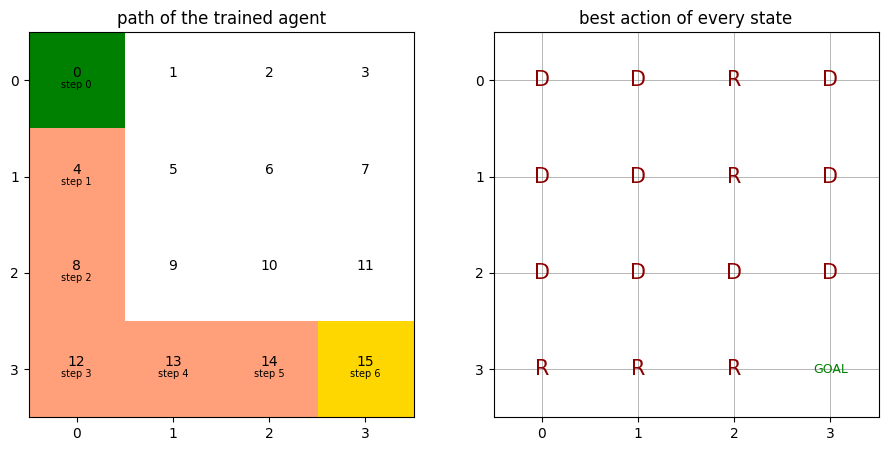

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(['white', 'lightsalmon', 'green', 'gold'])
img = np.zeros((4,4))
for s in path:
    img[divmod(s, 4)] = 1
img[0, 0] = 2
img[3, 3] = 3

plt.figure(figsize=(11,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap=cmap, vmin=0, vmax=3)
for s in range(16):
    r, cl = divmod(s, 4)
    plt.text(cl, r, str(s), ha='center', va='bottom', fontsize=10)
    if s in path:
        plt.text(cl, r, "step " + str(path.index(s)), ha='center', va='top', fontsize=7)
plt.title("path of the trained agent")
plt.xticks(range(4)); plt.yticks(range(4))

plt.subplot(1,2,2)
plt.imshow(np.zeros((4,4)), cmap='Greys', vmin=0, vmax=1)
for s in range(16):
    r, cl = divmod(s, 4)
    if s == 15:
        plt.text(cl, r, "GOAL", ha='center', va='center', color='green', fontsize=9)
        continue
    plt.text(cl, r, letters[int(np.argmax(Q[s]))], ha='center', va='center',
             fontsize=15, color='darkred')
plt.title("best action of every state")
plt.xticks(range(4)); plt.yticks(range(4))
plt.grid(color='gray', linewidth=0.4)
plt.show()


How many times was each state visited. This shows which part of the grid the agent used the most while learning.


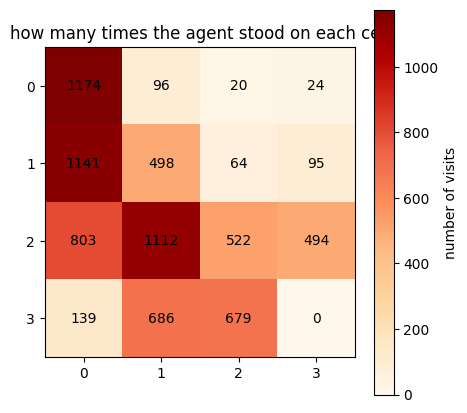

most visited state : 0 with 1174 visits
state 15 visits : 0 (it is the goal, the episode ends there)


In [9]:
plt.figure(figsize=(5,5))
plt.imshow(visits.reshape(4,4), cmap='OrRd')
plt.colorbar(label="number of visits")
for s in range(16):
    r, cl = divmod(s, 4)
    plt.text(cl, r, int(visits[s]), ha='center', va='center', fontsize=10)
plt.title("how many times the agent stood on each cell")
plt.xticks(range(4)); plt.yticks(range(4))
plt.show()

print("most visited state :", int(np.argmax(visits)), "with", int(visits.max()), "visits")
print("state 15 visits :", int(visits[15]), "(it is the goal, the episode ends there)")


Steps taken in each episode. The first episode is the longest because the agent knows nothing, and it comes down very quickly after that.


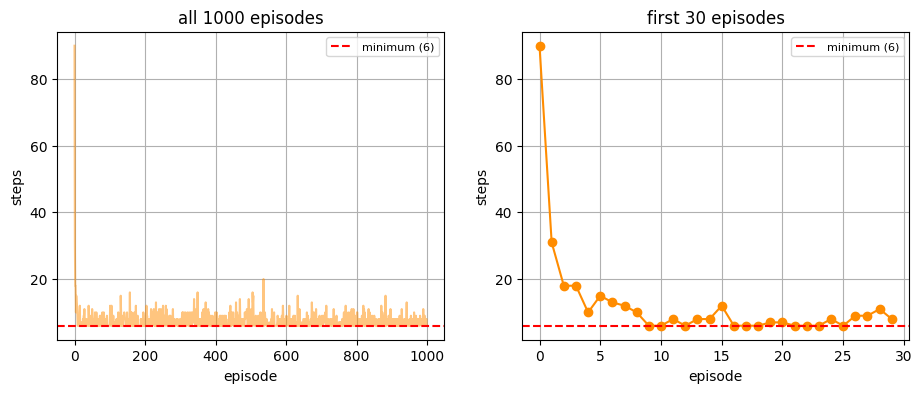

In [10]:
plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(steps_per_episode, alpha=0.5, color='darkorange')
plt.axhline(6, color='red', linestyle='--', label="minimum (6)")
plt.xlabel("episode"); plt.ylabel("steps")
plt.title("all 1000 episodes")
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(steps_per_episode[:30], 'o-', color='darkorange')
plt.axhline(6, color='red', linestyle='--', label="minimum (6)")
plt.xlabel("episode"); plt.ylabel("steps")
plt.title("first 30 episodes")
plt.legend(fontsize=8); plt.grid(True)
plt.show()


The training is repeated with a smaller number of episodes to find out after how many episodes the agent is already able to reach the goal.

Here we have used a step limit is used while reading the path, because when the training is very less the greedy policy can go in a circle between two cells and the loop will never finish.


In [11]:
def train_and_test(n_episodes, seed=3):
    random.seed(seed)
    Qx = np.zeros((16, 4))
    for episode in range(n_episodes):
        state = 0
        while state != 15:
            if random.random() < epsilon:
                action = random.randint(0, 3)
            else:
                action = np.argmax(Qx[state])
            new_state = next_state(state, action)
            reward = 10 if new_state == 15 else -1
            Qx[state, action] += alpha * (
                reward + gamma * np.max(Qx[new_state]) - Qx[state, action]
            )
            state = new_state

    # reading the path with a limit of 20 moves
    s = 0
    p = [0]
    for i in range(20):
        s = next_state(s, int(np.argmax(Qx[s])))
        p.append(s)
        if s == 15:
            break
    return p

for n in [1, 2, 5, 10, 25, 50, 100, 1000]:
    p = train_and_test(n)
    if p[-1] == 15:
        print("episodes =", str(n).rjust(4), ": goal reached in", len(p)-1, "moves")
    else:
        print("episodes =", str(n).rjust(4), ": goal not reached in 20 moves, policy is going in a loop")


episodes =    1 : goal not reached in 20 moves, policy is going in a loop
episodes =    2 : goal not reached in 20 moves, policy is going in a loop
episodes =    5 : goal not reached in 20 moves, policy is going in a loop
episodes =   10 : goal reached in 6 moves
episodes =   25 : goal reached in 6 moves
episodes =   50 : goal reached in 6 moves
episodes =  100 : goal reached in 6 moves
episodes = 1000 : goal reached in 6 moves


*Observation*: <br>With only 1, 2 or 5 episodes the agent has not seen the goal enough number of times, the values are still mostly zero and the greedy policy keeps moving between the same cells, that is why the goal is not reached inside 20 moves.

From 10 episodes onwards the path is already the shortest one of 6 moves, and it stays the same for 25, 50, 100 and 1000 episodes.


## 8. Result
The Q-Learning algorithm was successfully implemented in Python, and the agent learned an optimal path from the starting state to the goal through repeated interaction with the environment.

The Q-table started from all zeros and after the training it holds the expected reward of every state and action pair. The greedy policy taken from this table gives a path of 6 moves from state 0 to state 15, which is the shortest possible path in a 4x4 grid, and the number of steps per episode came down from a very long first episode to nearly this minimum.


## 9. Conclusion
Reinforcement learning was implemented using the Q-Learning algorithm and an agent was trained to find the optimal path in a 4x4 grid world.

The result shows that the agent is able to learn the correct behaviour only from the rewards returned by the environment, without being told the position of the goal. The table which was initialised with zeros gets filled step by step using the Q-Learning update, and the action having the maximum value in each row forms a complete policy which reaches the goal from every cell of the grid and not only from the starting cell.

The heatmap of the visits shows that the agent did not spend an equal amount of time everywhere. The cells lying on the route which the agent settled down on were visited more than a thousand times, state 0 with 1174 visits and state 4 with 1141, while the cells of the top right corner which are away from that route were visited only 20 and 24 times. This is the natural effect of exploitation, the agent keeps using the path which it already believes to be good and rarely goes to the other side of the grid.

The study of the number of episodes shows that the agent does not need all the thousand episodes for this environment. In the first few episodes the policy is still incomplete and the greedy path goes in a loop, but after about ten episodes the agent is already able to reach the goal in the minimum number of moves, and the remaining episodes only make the values in the table more accurate.

It is concluded that Q-Learning works well for a small and discrete environment like this grid, where the whole table can be stored in memory and every state can be visited many times. For bigger problems the size of the table grows very fast and a neural network is used in place of the table, which is called Deep Q Learning.


## 10. Some important questions

**1. What is Reinforcement Learning?**  
It is a type of machine learning where an agent learns by interacting with an environment and receiving rewards or penalties, instead of learning from a labelled dataset.

**2. What is an agent and an environment?**  
The agent takes the decisions, here it is the robot in the grid. The environment is the grid itself, which gives the next state and the reward for every action taken by the agent.

**3. What is a reward?**  
It is the number given by the environment after every action and it tells whether the action was good or bad. In this program reaching state 15 gives +10 and every other move gives -1.

**4. What is Q-Learning?**  
It is a model free reinforcement learning algorithm which learns the expected reward Q(s,a) for every state and action pair, without knowing the rules of the environment in advance.

**5. What is the purpose of a Q-table?**  
It stores what the agent has learnt. Each row is a state, each column is an action, and after training the best action of a state is the one having the maximum value in that row.

**6. What is the difference between exploration and exploitation?**  
Exploration means trying a random action to discover something new, exploitation means using the best action known so far. Here epsilon = 0.2, so about 20 percent of the moves are exploration and 80 percent are exploitation.

**7. What do alpha and gamma represent?**  
Alpha is the learning rate and it controls how much the new experience changes the old value. Gamma is the discount factor and it controls how much importance is given to the future rewards. Here alpha = 0.8 so the learning is fast, and gamma = 0.95 so the future rewards are almost as important as the immediate ones.
